# Task 5: Auto Tagging Support Tickets Using LLM

**Objective:** Automatically tag support tickets into categories using prompt engineering with an LLM.

**Model:** LLaMA 3.3 70B via Groq API (free)

**Skills:** Prompt engineering, zero-shot learning, few-shot learning, LLM-based text classification

## 1. Install Dependencies

In [1]:
!pip install groq pandas matplotlib seaborn -q
print('Dependencies ready.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 6.2 MB/s eta 0:00:00
Dependencies ready.


## 2. Import Libraries and Configure Groq API

In [2]:
import json
import re
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from groq import Groq

# -------------------------------------------------------
# PASTE YOUR GROQ API KEY HERE
API_KEY = "gsk_XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX"
# -------------------------------------------------------

client = Groq(api_key=API_KEY)
MODEL  = 'llama-3.3-70b-versatile'

print('Configuration done.')

Configuration done.


## 3. Define the Support Ticket Dataset

A synthetic set of free-text support tickets across multiple categories.

In [11]:
tickets = [
    {"id": 1,  "text": "My internet connection keeps dropping every few minutes. I've restarted the router multiple times but it doesn't help.", "true_tag": "Connectivity"},
    {"id": 2,  "text": "I was charged twice for my subscription this month. Please refund the extra payment immediately.", "true_tag": "Billing"},
    {"id": 3,  "text": "The app crashes every time I try to open the settings menu on my Android phone.", "true_tag": "App Bug"},
    {"id": 4,  "text": "I forgot my password and the reset email is not arriving in my inbox or spam folder.", "true_tag": "Account Access"},
    {"id": 5,  "text": "How do I upgrade my plan to include more storage? I can't find the option in my dashboard.", "true_tag": "Billing"},
    {"id": 6,  "text": "Videos are buffering constantly even though I have fast internet. Other sites work fine.", "true_tag": "Performance"},
    {"id": 7,  "text": "I received an error message saying my account has been suspended. I haven't violated any terms.", "true_tag": "Account Access"},
    {"id": 8,  "text": "The dark mode feature is not saving my preference. It resets to light mode every time I log in.", "true_tag": "App Bug"},
    {"id": 9,  "text": "I need an invoice for my last three payments for tax purposes.", "true_tag": "Billing"},
    {"id": 10, "text": "My download speed is extremely slow, only getting 1 Mbps when I should get 100 Mbps.", "true_tag": "Connectivity"},
    {"id": 11, "text": "The search function is returning wrong results. It's not finding documents I know exist.", "true_tag": "App Bug"},
    {"id": 12, "text": "I want to cancel my account and get a refund for the unused portion of my subscription.", "true_tag": "Billing"},
    {"id": 13, "text": "Pages are taking 10 to 15 seconds to load. This started happening after the last update.", "true_tag": "Performance"},
    {"id": 14, "text": "I can't log in with my Google account. It keeps saying authentication failed.", "true_tag": "Account Access"},
    {"id": 15, "text": "WiFi signal is weak in some areas of my office but strong in others. Could be a coverage issue.", "true_tag": "Connectivity"},
]

df = pd.DataFrame(tickets)
print(f'Total tickets: {len(df)}')
print('\nTag distribution:')
print(df['true_tag'].value_counts())
df.head()

Total tickets: 15

Tag distribution:
true_tag
Billing           4
Connectivity      3
App Bug           3
Account Access    3
Performance       2
Name: count, dtype: int64


,id,text,true_tag
0,1,My internet connection keeps dropping every fe...,Connectivity
1,2,I was charged twice for my subscription this m...,Billing
2,3,The app crashes every time I try to open the s...,App Bug
3,4,I forgot my password and the reset email is no...,Account Access
4,5,How do I upgrade my plan to include more stora...,Billing


## 4. Define Available Tags

In [4]:
AVAILABLE_TAGS = [
    "Billing",
    "Connectivity",
    "App Bug",
    "Account Access",
    "Performance",
    "Feature Request",
    "Security",
    "Other"
]

print(f'Available tags: {AVAILABLE_TAGS}')

Available tags: ['Billing', 'Connectivity', 'App Bug', 'Account Access', 'Performance', 'Feature Request', 'Security', 'Other']


## 5. Zero-Shot Tagging

The model predicts tags with no examples — only the task description.

In [5]:
def zero_shot_tag(ticket_text: str) -> list:
    """
    Zero-shot: tag the ticket using only task description, no examples.
    Returns top 3 most probable tags.
    """
    prompt = f"""You are a support ticket classification system.

Classify the following support ticket into the top 3 most relevant tags from this list:
{', '.join(AVAILABLE_TAGS)}

Return ONLY a JSON object in this exact format:
{{"tags": ["Tag1", "Tag2", "Tag3"]}}

Support Ticket:
\"{ticket_text}\"

JSON Response:"""

    response = client.chat.completions.create(
        model=MODEL,
        messages=[{"role": "user", "content": prompt}],
        max_tokens=100,
        temperature=0.1
    )

    raw = response.choices[0].message.content.strip()
    try:
        # Extract JSON from response
        match = re.search(r'\{.*\}', raw, re.DOTALL)
        result = json.loads(match.group())
        return result.get('tags', [])[:3]
    except:
        return [raw]

print('Zero-shot function defined.')

Zero-shot function defined.


## 6. Few-Shot Tagging

The model is given examples before making predictions — improves accuracy.

In [6]:
FEW_SHOT_EXAMPLES = """
Example 1:
Ticket: "I can't log in to my account, it keeps saying incorrect password."
Tags: {"tags": ["Account Access", "App Bug", "Other"]}

Example 2:
Ticket: "My internet speed dropped from 100Mbps to 5Mbps after the maintenance window."
Tags: {"tags": ["Connectivity", "Performance", "Other"]}

Example 3:
Ticket: "I was billed for a premium plan I never signed up for. Please reverse the charge."
Tags: {"tags": ["Billing", "Account Access", "Other"]}

Example 4:
Ticket: "The mobile app freezes on the home screen after the latest update."
Tags: {"tags": ["App Bug", "Performance", "Other"]}
"""

def few_shot_tag(ticket_text: str) -> list:
    """
    Few-shot: tag the ticket using task description + examples.
    Returns top 3 most probable tags.
    """
    prompt = f"""You are a support ticket classification system.

Classify support tickets into the top 3 most relevant tags from this list:
{', '.join(AVAILABLE_TAGS)}

Here are some examples:
{FEW_SHOT_EXAMPLES}

Now classify this ticket. Return ONLY a JSON object in this exact format:
{{"tags": ["Tag1", "Tag2", "Tag3"]}}

Support Ticket:
\"{ticket_text}\"

JSON Response:"""

    response = client.chat.completions.create(
        model=MODEL,
        messages=[{"role": "user", "content": prompt}],
        max_tokens=100,
        temperature=0.1
    )

    raw = response.choices[0].message.content.strip()
    try:
        match = re.search(r'\{.*\}', raw, re.DOTALL)
        result = json.loads(match.group())
        return result.get('tags', [])[:3]
    except:
        return [raw]

print('Few-shot function defined.')

Few-shot function defined.


## 7. Run Both Methods on All Tickets

In [7]:
zero_shot_results = []
few_shot_results  = []

print('Running zero-shot and few-shot tagging...\n')

for _, row in df.iterrows():
    zs_tags = zero_shot_tag(row['text'])
    fs_tags = few_shot_tag(row['text'])

    zero_shot_results.append(zs_tags)
    few_shot_results.append(fs_tags)

    print(f"Ticket #{row['id']}")
    print(f"  Text      : {row['text'][:70]}...")
    print(f"  True tag  : {row['true_tag']}")
    print(f"  Zero-shot : {zs_tags}")
    print(f"  Few-shot  : {fs_tags}")
    print()
    time.sleep(0.5)   # avoid rate limit

df['zero_shot_tags'] = zero_shot_results
df['few_shot_tags']  = few_shot_results

print('Done.')

Running zero-shot and few-shot tagging...

Ticket #1
  Text      : My internet connection keeps dropping every few minutes. I've restarte...
  True tag  : Connectivity
  Zero-shot : ['Connectivity', 'Performance', 'Account Access']
  Few-shot  : ['Connectivity', 'Performance', 'Other']

Ticket #2
  Text      : I was charged twice for my subscription this month. Please refund the ...
  True tag  : Billing
  Zero-shot : ['Billing', 'Account Access', 'Security']
  Few-shot  : ['Billing', 'Account Access', 'Security']

Ticket #3
  Text      : The app crashes every time I try to open the settings menu on my Andro...
  True tag  : App Bug
  Zero-shot : ['App Bug', 'Connectivity', 'Performance']
  Few-shot  : ['App Bug', 'Performance', 'Other']

Ticket #4
  Text      : I forgot my password and the reset email is not arriving in my inbox o...
  True tag  : Account Access
  Zero-shot : ['Account Access', 'Security', 'Connectivity']
  Few-shot  : ['Account Access', 'App Bug', 'Security']

Ticket

## 8. Evaluate Performance

We check whether the true tag appears in the top 3 predicted tags (Top-1 and Top-3 accuracy).

In [8]:
def top1_correct(true_tag, predicted_tags):
    """Check if the top predicted tag matches the true tag."""
    return len(predicted_tags) > 0 and predicted_tags[0] == true_tag

def top3_correct(true_tag, predicted_tags):
    """Check if the true tag appears anywhere in top 3 predictions."""
    return true_tag in predicted_tags

df['zs_top1'] = df.apply(lambda r: top1_correct(r['true_tag'], r['zero_shot_tags']), axis=1)
df['zs_top3'] = df.apply(lambda r: top3_correct(r['true_tag'], r['zero_shot_tags']), axis=1)
df['fs_top1'] = df.apply(lambda r: top1_correct(r['true_tag'], r['few_shot_tags']),  axis=1)
df['fs_top3'] = df.apply(lambda r: top3_correct(r['true_tag'], r['few_shot_tags']),  axis=1)

results_summary = {
    'Method':       ['Zero-Shot', 'Few-Shot'],
    'Top-1 Accuracy': [
        f"{df['zs_top1'].mean()*100:.1f}%",
        f"{df['fs_top1'].mean()*100:.1f}%"
    ],
    'Top-3 Accuracy': [
        f"{df['zs_top3'].mean()*100:.1f}%",
        f"{df['fs_top3'].mean()*100:.1f}%"
    ]
}

results_df = pd.DataFrame(results_summary)
print('Performance Comparison:')
print(results_df.to_string(index=False))

Performance Comparison:
   Method Top-1 Accuracy Top-3 Accuracy
Zero-Shot          93.3%         100.0%
 Few-Shot          86.7%         100.0%


## 9. Visualise Results

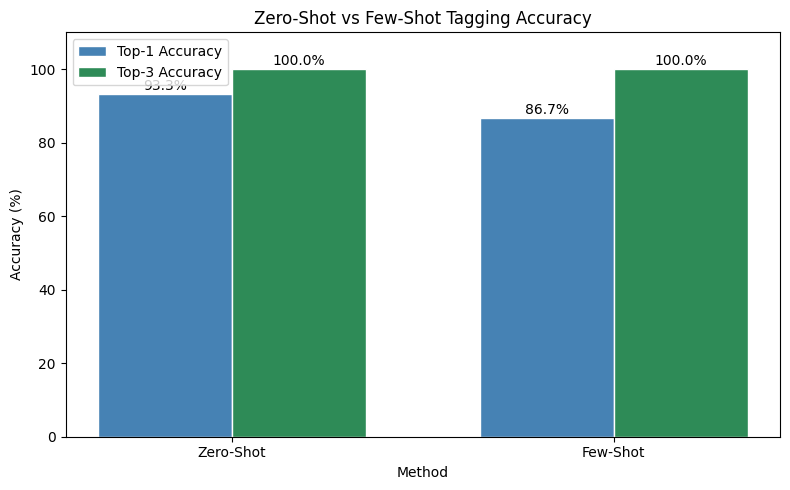

In [9]:
# Accuracy comparison bar chart
methods   = ['Zero-Shot', 'Few-Shot']
top1_vals = [df['zs_top1'].mean()*100, df['fs_top1'].mean()*100]
top3_vals = [df['zs_top3'].mean()*100, df['fs_top3'].mean()*100]

x = range(len(methods))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar([i - width/2 for i in x], top1_vals, width,
                label='Top-1 Accuracy', color='steelblue', edgecolor='white')
bars2 = ax.bar([i + width/2 for i in x], top3_vals, width,
                label='Top-3 Accuracy', color='seagreen', edgecolor='white')

ax.set_xlabel('Method')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Zero-Shot vs Few-Shot Tagging Accuracy')
ax.set_xticks(list(x))
ax.set_xticklabels(methods)
ax.set_ylim(0, 110)
ax.legend()

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height():.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('tagging_accuracy.png', dpi=150)
plt.show()

In [10]:
# Show full results table
display_cols = ['id', 'true_tag', 'zero_shot_tags', 'few_shot_tags', 'zs_top1', 'fs_top1']
print('Full Results Table:')
print(df[display_cols].to_string(index=False))

Full Results Table:
 id       true_tag                              zero_shot_tags                              few_shot_tags  zs_top1  fs_top1
  1   Connectivity [Connectivity, Performance, Account Access]         [Connectivity, Performance, Other]     True     True
  2        Billing         [Billing, Account Access, Security]        [Billing, Account Access, Security]     True     True
  3        App Bug        [App Bug, Connectivity, Performance]              [App Bug, Performance, Other]     True     True
  4 Account Access    [Account Access, Security, Connectivity]        [Account Access, App Bug, Security]     True     True
  5        Billing      [Billing, Account Access, Performance] [Account Access, Billing, Feature Request]     True    False
  6    Performance        [Connectivity, Performance, App Bug]       [Connectivity, Performance, App Bug]    False    False
  7 Account Access         [Account Access, Security, Billing]          [Account Access, Security, Other]     Tr